# Прогноз потребности по артикулам (Активный телеком)

**Задача:** на основе выгрузки «Продажи по клиентам» (1С, апрель 2024 — сентябрь 2026) подготовить данные и построить прогноз спроса (в штуках) на **октябрь–декабрь 2026** по каждому артикулу.

**Подход:**
1. Парсинг иерархического отчёта 1С (Контрагент → Номенклатура → Регистратор) в «длинный» формат.
2. Валидация парсинга по контрольной строке «Итого».
3. EDA: динамика спроса, ABC/XYZ-анализ, прерывистость спроса.
4. Создание признаков (лаги, скользящие статистики, календарь).
5. Задача регрессии: глобальная модель **LightGBM** на панели «артикул × месяц», сравнение с наивными бейзлайнами по WAPE/SMAPE/MAE/RMSE.
6. Финальный прогноз на 3 месяца вперёд по каждому артикулу.

**Входной файл:** `Активный телеком_больше данных.xlsx` (положите рядом с ноутбуком или загрузите в Kaggle Input).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (12, 4)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Путь к файлу: локально, в sandbox или на Kaggle
CANDIDATES = [
    'Активный телеком_больше данных.xlsx',
    '/mnt/agents/upload/Активный телеком_больше данных.xlsx',
]
# поиск на Kaggle
if os.path.exists('/kaggle/input'):
    for root, _, files in os.walk('/kaggle/input'):
        for f in files:
            if f.endswith('.xlsx') and 'телеком' in f.lower():
                CANDIDATES.insert(0, os.path.join(root, f))

DATA_PATH = next(p for p in CANDIDATES if os.path.exists(p))
print('Файл данных:', DATA_PATH)

Файл данных: Активный телеком_больше данных.xlsx


## 1. Парсинг отчёта 1С в «длинный» формат

Структура листа: строки 1–8 — шапка отчёта; далее иерархия **Контрагент → Номенклатура (с колонкой «Артикул») → Регистратор (документ)**.
Колонки 0–5 — иерархия, далее блоки по 5 колонок на каждый месяц: *Количество, Сумма продажи, Себестоимость, Валовая прибыль, Рентабельность*, в конце — блок «Итого».

Берём **только строки номенклатуры** (у них заполнен артикул): они уже содержат подытог по связке «клиент × товар», а строки документов — детализация, которую нельзя суммировать вместе с ними (был бы двойной счёт).

In [2]:
raw = pd.read_excel(DATA_PATH, sheet_name=0, header=None)

# блоки месяцев: каждые 5 колонок, начиная с 6-й, до блока 'Итого'
month_blocks = []
c = 6
while c < raw.shape[1]:
    v = raw.iat[6, c]
    if pd.isna(v) or str(v).strip() == 'Итого':
        break
    month_blocks.append((c, pd.to_datetime(v, dayfirst=True)))
    c += 5
print(f'Месяцев: {len(month_blocks)} | {month_blocks[0][1]:%m.%Y} — {month_blocks[-1][1]:%m.%Y}')

records = []
cur_client = None
for i in range(9, len(raw)):
    label = raw.iat[i, 0]
    if pd.isna(label):
        continue
    label = str(label).strip()
    if label == 'Итого':
        break
    art = raw.iat[i, 4]
    if pd.notna(art):                       # строка номенклатуры
        item = label
        article = str(art).strip()
        for c0, mdate in month_blocks:
            qty    = pd.to_numeric(raw.iat[i, c0],   errors='coerce')
            sales  = pd.to_numeric(raw.iat[i, c0+1], errors='coerce')
            cost   = pd.to_numeric(raw.iat[i, c0+2], errors='coerce')
            profit = pd.to_numeric(raw.iat[i, c0+3], errors='coerce')
            if pd.isna(qty) and pd.isna(sales):
                continue
            records.append((article, item, cur_client, mdate, qty, sales, cost, profit))
    elif not label.startswith('Реализация'):  # не документ -> клиент
        cur_client = label

long_df = pd.DataFrame(records, columns=['article', 'item_name', 'client', 'month',
                                         'qty', 'sales', 'cost', 'profit'])
print(long_df.shape)
print('Артикулов:', long_df.article.nunique(), '| Клиентов:', long_df.client.nunique())
long_df.head()

Месяцев: 30 | 04.2024 — 09.2026
(2232, 8)
Артикулов: 41 | Клиентов: 238


,article,item_name,client,month,qty,sales,cost,profit
0,TSX-U-8T,Промышленный неуправляемый коммутатор U-8T TSX...,50 Герц ООО,2026-06-01,2.00,"10,612.52","4,144.33","6,468.19"
1,TSX-U-5T,Промышленный неуправляемый коммутатор U-5T TSX...,A&G SERVICES,2025-07-01,90.00,"203,239.09","149,673.27","53,565.82"
2,TSX-U-5T,Промышленный неуправляемый коммутатор U-5T TSX...,A&G SERVICES,2025-09-01,66.00,"151,008.65","87,903.39","63,105.26"
3,TSX-U-5T,Промышленный неуправляемый коммутатор U-5T TSX...,A&G SERVICES,2026-01-01,138.00,"275,597.56","192,976.71","82,620.85"
4,TSX-U-16T,Промышленный неуправляемый коммутатор U-16T TS...,All Prof-Electro ТОО,2024-11-01,3.00,"33,220.25","22,702.23","10,518.02"


## 2. Валидация парсинга
Сверяем суммы с контрольной строкой «Итого» исходного отчёта. Отрицательные значения `qty` — это возвраты, оставляем их как есть (чистый спрос).

In [3]:
total_row = raw[raw[0].astype(str).str.strip() == 'Итого'].iloc[0]
check = pd.DataFrame({
    'parsed':  [long_df.qty.sum(), long_df.sales.sum(), long_df.cost.sum(), long_df.profit.sum()],
    'report':  [pd.to_numeric(total_row[156], errors='coerce'), pd.to_numeric(total_row[157], errors='coerce'),
                pd.to_numeric(total_row[158], errors='coerce'), pd.to_numeric(total_row[159], errors='coerce')],
}, index=['qty', 'sales', 'cost', 'profit'])
check['diff'] = check.parsed - check.report
print(check)
assert np.allclose(check.parsed, check.report), 'Расхождение с отчётом!'
print('\nПарсинг корректен. Строк с возвратами (qty<0):', (long_df.qty < 0).sum())

long_df.to_csv('продажи_детально.csv', index=False)
print('Сохранено: продажи_детально.csv')

               parsed         report  diff
qty         23,797.00      23,797.00  0.00
sales  138,190,640.58 138,190,640.58 -0.00
cost    59,339,498.92  59,339,498.92  0.00
profit  78,851,141.66  78,851,141.66  0.00

Парсинг корректен. Строк с возвратами (qty<0): 151
Сохранено: продажи_детально.csv


## 3. Панель «артикул × месяц»
Агрегируем по всем клиентам и приводим к полной сетке месяцев: месяцы без продаж = 0 (важно для лагов и модели).

In [4]:
panel = (long_df.groupby(['article', 'item_name', 'month'], as_index=False)
         .agg(qty=('qty', 'sum'), sales=('sales', 'sum'), cost=('cost', 'sum'),
              profit=('profit', 'sum'), n_clients=('client', 'nunique')))

all_months = pd.date_range(panel.month.min(), panel.month.max(), freq='MS')
arts = long_df[['article', 'item_name']].drop_duplicates('article')
df = (arts.merge(pd.DataFrame({'month': all_months}), how='cross')
          .merge(panel, on=['article', 'item_name', 'month'], how='left'))
for col in ['qty', 'sales', 'cost', 'profit']:
    df[col] = df[col].fillna(0)
df['n_clients'] = df['n_clients'].fillna(0).astype(int)
df['price'] = np.where(df.qty > 0, df.sales / df.qty, np.nan)  # средняя цена при продажах
df = df.sort_values(['article', 'month']).reset_index(drop=True)
print(df.shape)
df.to_csv('панель_спроса.csv', index=False)
print('Сохранено: панель_спроса.csv')
df.head()

(1230, 9)
Сохранено: панель_спроса.csv


,article,item_name,month,qty,sales,cost,profit,n_clients,price
0,TSX-MC-1GX1GT-FC,Медиаконвертер MC-1GX1GT-FC двойное одномодово...,2024-04-01,0.00,0.00,0.00,0.00,0,NaN
1,TSX-MC-1GX1GT-FC,Медиаконвертер MC-1GX1GT-FC двойное одномодово...,2024-05-01,0.00,0.00,0.00,0.00,0,NaN
2,TSX-MC-1GX1GT-FC,Медиаконвертер MC-1GX1GT-FC двойное одномодово...,2024-06-01,12.00,"82,560.00","36,438.54","46,121.46",2,"6,880.00"
3,TSX-MC-1GX1GT-FC,Медиаконвертер MC-1GX1GT-FC двойное одномодово...,2024-07-01,0.00,0.00,0.00,0.00,0,NaN
4,TSX-MC-1GX1GT-FC,Медиаконвертер MC-1GX1GT-FC двойное одномодово...,2024-08-01,0.00,0.00,0.00,0.00,0,NaN


## 4. EDA

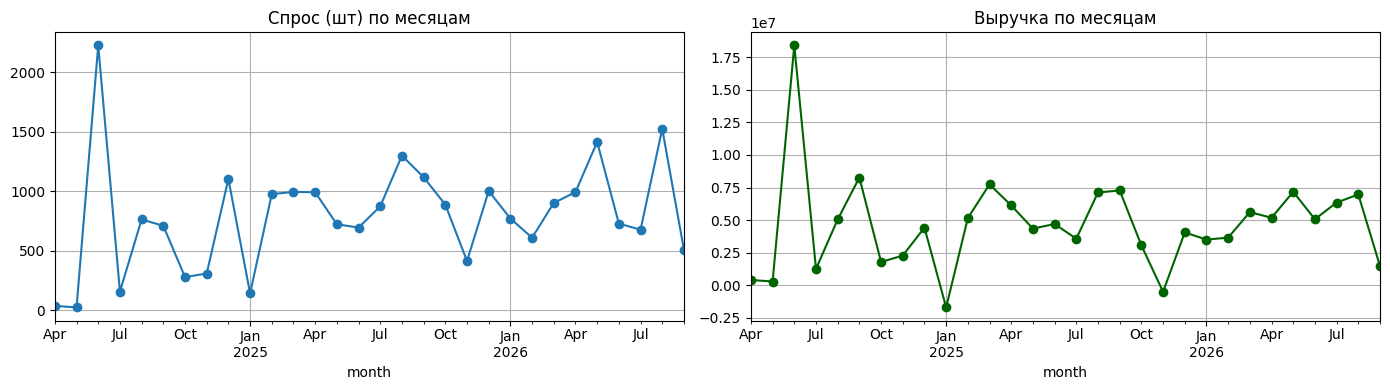

Всего продано, шт: 23797 | Выручка: 138,190,641


In [5]:
# 4.1. Общая динамика спроса и выручки
tot = df.groupby('month')[['qty', 'sales']].sum()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
tot.qty.plot(ax=ax[0], marker='o', title='Спрос (шт) по месяцам', grid=True)
tot.sales.plot(ax=ax[1], marker='o', color='darkgreen', title='Выручка по месяцам', grid=True)
plt.tight_layout(); plt.show()

print('Всего продано, шт:', int(tot.qty.sum()), '| Выручка:', f"{tot.sales.sum():,.0f}")

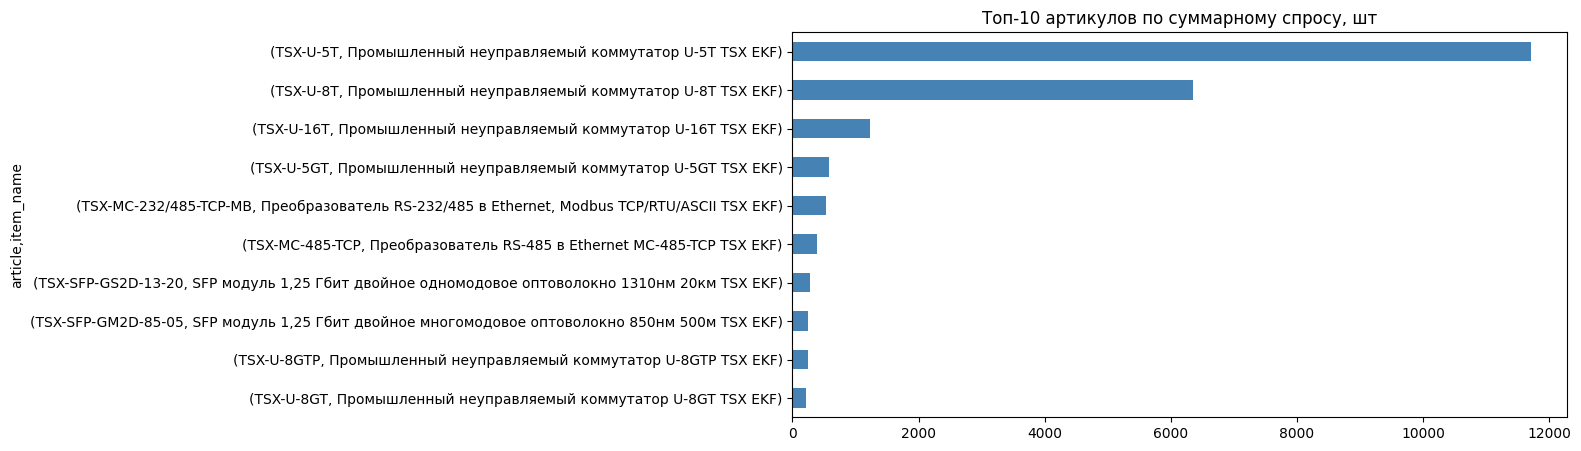

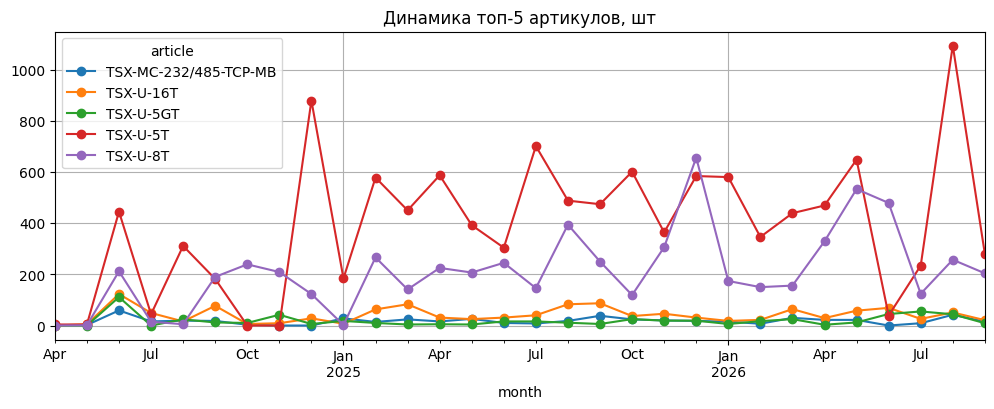

In [6]:
# 4.2. Топ-10 артикулов по объёму
top10 = df.groupby(['article', 'item_name']).qty.sum().sort_values(ascending=False).head(10)
ax = top10.sort_values().plot.barh(figsize=(10, 5), color='steelblue', title='Топ-10 артикулов по суммарному спросу, шт')
plt.show()

# динамика топ-5
top5 = top10.head(5).index.get_level_values(0)
piv = df[df.article.isin(top5)].pivot(index='month', columns='article', values='qty')
piv.plot(marker='o', figsize=(12, 4), grid=True, title='Динамика топ-5 артикулов, шт')
plt.show()

In [7]:
# 4.3. ABC-XYZ анализ
stat = df.groupby('article').qty.agg(total='sum', mean='mean', std='std')
stat['share'] = stat.total / stat.total.sum()
stat = stat.sort_values('total', ascending=False)
stat['cum_share'] = stat.share.cumsum()
stat['ABC'] = np.where(stat.cum_share <= 0.80, 'A', np.where(stat.cum_share <= 0.95, 'B', 'C'))
stat['CV'] = stat['std'] / stat['mean'].replace(0, np.nan)   # коэффициент вариации
stat['XYZ'] = np.where(stat.CV <= 0.5, 'X', np.where(stat.CV <= 1.0, 'Y', 'Z'))
stat['zero_share'] = df.assign(z=df.qty == 0).groupby('article').z.mean()

print(stat[['total', 'share', 'cum_share', 'CV', 'ABC', 'XYZ', 'zero_share']]
      .style.format({'share': '{:.1%}', 'cum_share': '{:.1%}', 'CV': '{:.2f}', 'zero_share': '{:.0%}'}))
print('\nМатрица ABC-XYZ:')
print(stat.groupby(['ABC', 'XYZ']).size().unstack(fill_value=0))


Матрица ABC-XYZ:
XYZ  Y   Z
ABC       
A    2   0
B    2  11
C    0  26


**Выводы EDA.** Спрос концентрирован: 3 артикула (TSX-U-5T, TSX-U-8T, TSX-U-16T) дают основную часть объёма.
У длинного хвоста номенклатуры спрос прерывистый (много нулевых месяцев) — для таких позиций прогноз ограниченно точен,
на практике их стоит планировать страховым запасом или методами для прерывистого спроса (Croston/TSB).

## 5. Признаки для регрессионной модели

Глобальная модель (одна на все артикулы) на панели «артикул × месяц»:
- **лаги** спроса: 1, 2, 3, 6, 12 месяцев;
- **скользящие статистики**: среднее и std за 3 и 6 месяцев (со сдвигом на 1, чтобы не подглядывать в будущее);
- средняя цена и её лаг;
- число активных клиентов (лаг 1);
- **календарь**: месяц (sin/cos), квартал, год, номер месяца от старта (тренд);
- артикул как категориальный признак.

In [8]:
FEATURE_LAGS = [1, 2, 3, 6, 12]

def make_features(d):
    d = d.sort_values(['article', 'month']).copy()
    g = d.groupby('article', observed=True)
    for l in FEATURE_LAGS:
        d[f'qty_lag_{l}'] = g.qty.shift(l)
    # скользящие по сдвинутому ряду
    sh = g.qty.shift(1)
    d['roll_mean_3'] = sh.groupby(d.article, observed=True).rolling(3).mean().reset_index(level=0, drop=True)
    d['roll_mean_6'] = sh.groupby(d.article, observed=True).rolling(6).mean().reset_index(level=0, drop=True)
    d['roll_std_3']  = sh.groupby(d.article, observed=True).rolling(3).std().reset_index(level=0, drop=True)
    d['price_lag_1'] = g.price.shift(1)
    d['clients_lag_1'] = g.n_clients.shift(1)
    # календарь
    d['month_num'] = d.month.dt.month
    d['quarter'] = d.month.dt.quarter
    d['year'] = d.month.dt.year
    d['trend'] = ((d.month - d.month.min()).dt.days / 30.44).round().astype(int)
    d['month_sin'] = np.sin(2 * np.pi * d.month_num / 12)
    d['month_cos'] = np.cos(2 * np.pi * d.month_num / 12)
    d['article'] = d['article'].astype('category')  # категориальный признак для LightGBM
    return d

feat = make_features(df)
FEATURES = [f'qty_lag_{l}' for l in FEATURE_LAGS] +            ['roll_mean_3', 'roll_mean_6', 'roll_std_3', 'price_lag_1', 'clients_lag_1',
            'month_num', 'quarter', 'year', 'trend', 'month_sin', 'month_cos', 'article']
TARGET = 'qty'
feat.head()

,article,item_name,month,qty,sales,cost,profit,n_clients,price,qty_lag_1,...,roll_mean_6,roll_std_3,price_lag_1,clients_lag_1,month_num,quarter,year,trend,month_sin,month_cos
0,TSX-MC-1GX1GT-FC,Медиаконвертер MC-1GX1GT-FC двойное одномодово...,2024-04-01,0.00,0.00,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,4,2,2024,0,0.87,-0.50
1,TSX-MC-1GX1GT-FC,Медиаконвертер MC-1GX1GT-FC двойное одномодово...,2024-05-01,0.00,0.00,0.00,0.00,0,NaN,0.00,...,NaN,NaN,NaN,0.00,5,2,2024,1,0.50,-0.87
2,TSX-MC-1GX1GT-FC,Медиаконвертер MC-1GX1GT-FC двойное одномодово...,2024-06-01,12.00,"82,560.00","36,438.54","46,121.46",2,"6,880.00",0.00,...,NaN,NaN,NaN,0.00,6,2,2024,2,0.00,-1.00
3,TSX-MC-1GX1GT-FC,Медиаконвертер MC-1GX1GT-FC двойное одномодово...,2024-07-01,0.00,0.00,0.00,0.00,0,NaN,12.00,...,NaN,6.93,"6,880.00",2.00,7,3,2024,3,-0.50,-0.87
4,TSX-MC-1GX1GT-FC,Медиаконвертер MC-1GX1GT-FC двойное одномодово...,2024-08-01,0.00,0.00,0.00,0.00,0,NaN,0.00,...,NaN,6.93,NaN,0.00,8,3,2024,4,-0.87,-0.50


## 6. Валидация: последние 3 месяца как тест
Метрики: **WAPE** (основная для планирования спроса), SMAPE, MAE, RMSE. Бейзлайны: наивный (спрос = прошлый месяц), сезонно-наивный (= год назад), скользящее среднее за 3 месяца.

In [9]:
H = 3  # горизонт теста
cutoff = df.month.max() - pd.offsets.MonthBegin(H - 1)
train = feat[feat.month < cutoff]
valid = feat[feat.month >= cutoff]
print(f'Train: {train.month.min():%m.%Y}—{train.month.max():%m.%Y} | Test: {valid.month.min():%m.%Y}—{valid.month.max():%m.%Y}')

def metrics(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    return {
        'MAE':   mean_absolute_error(y, p),
        'RMSE':  mean_squared_error(y, p) ** 0.5,
        'WAPE':  np.abs(y - p).sum() / max(np.abs(y).sum(), 1e-9),
        'SMAPE': np.mean(2 * np.abs(y - p) / (np.abs(y) + np.abs(p) + 1e-9)),
    }

preds = valid[['article', 'month', 'qty']].copy()
preds['naive']    = valid.qty_lag_1
preds['s_naive']  = valid.qty_lag_12.fillna(valid.qty_lag_1)
preds['ma3']      = valid.roll_mean_3.fillna(valid.qty_lag_1)
for c in ['naive', 's_naive', 'ma3']:
    preds[c] = preds[c].fillna(0).clip(lower=0)

rows = {b: metrics(preds.qty, preds[b]) for b in ['naive', 's_naive', 'ma3']}
base_scores = pd.DataFrame(rows).T
base_scores

Train: 04.2024—06.2026 | Test: 07.2026—09.2026


,MAE,RMSE,WAPE,SMAPE
naive,26.61,114.20,1.11,1.06
s_naive,21.71,74.32,0.91,1.20
ma3,19.33,81.21,0.81,1.14


In [10]:
# 6.1. LightGBM — глобальная регрессионная модель
X_train = train.dropna(subset=['qty_lag_1'])   # первые месяцы без истории не участвуют
lgb_train = lgb.Dataset(X_train[FEATURES], X_train[TARGET], categorical_feature=['article'])
lgb_valid = lgb.Dataset(valid[FEATURES], valid[TARGET], reference=lgb_train, categorical_feature=['article'])

params = dict(objective='regression', metric='l2', learning_rate=0.05, num_leaves=31,
              min_data_in_leaf=5, feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=1,
              verbose=-1, seed=42)
model = lgb.train(params, lgb_train, num_boost_round=2000, valid_sets=[lgb_valid],
                  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
print('best_iteration:', model.best_iteration)

preds['lightgbm'] = model.predict(valid[FEATURES]).clip(min=0)
scores = pd.concat([base_scores, pd.DataFrame({'lightgbm': metrics(preds.qty, preds.lightgbm)}).T])
scores.style.format('{:.3f}').highlight_min(axis=0, color='lightgreen')

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[624]	valid_0's l2: 4032.75
best_iteration: 624


,MAE,RMSE,WAPE,SMAPE
naive,26.610,114.200,1.113,1.060
s_naive,21.707,74.315,0.908,1.205
ma3,19.328,81.213,0.808,1.138
lightgbm,18.103,63.479,0.757,1.298


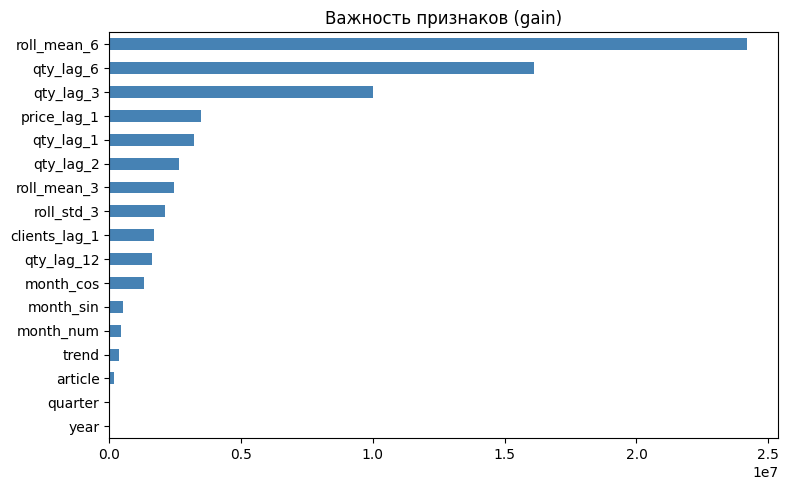

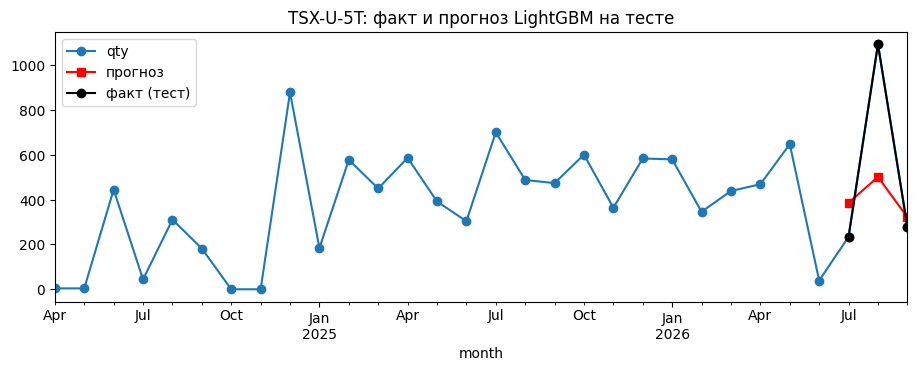

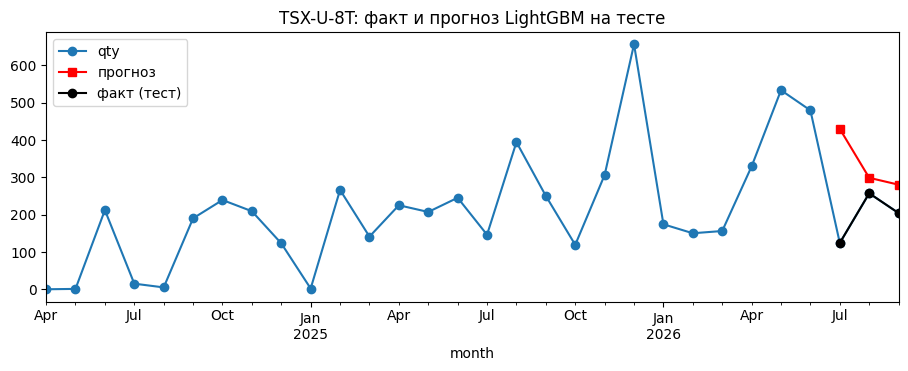

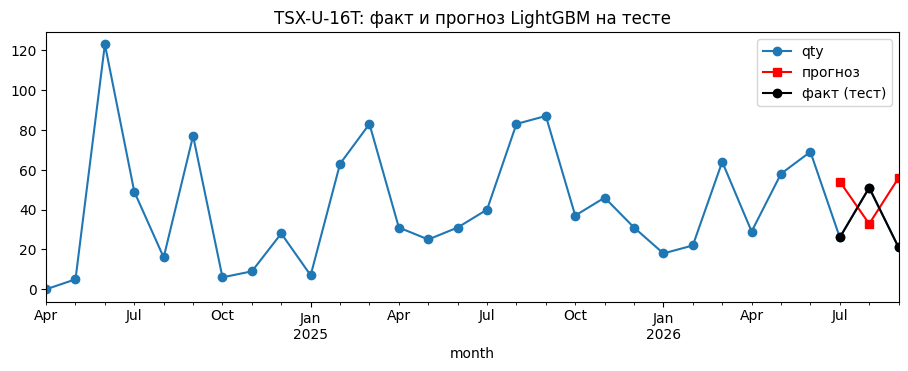

In [11]:
# 6.2. Важность признаков и визуализация прогноза на тесте
imp = pd.Series(model.feature_importance('gain'), index=FEATURES).sort_values()
imp.plot.barh(figsize=(8, 5), color='steelblue', title='Важность признаков (gain)')
plt.tight_layout(); plt.show()

top3 = df.groupby('article').qty.sum().nlargest(3).index
for a in top3:
    hist = df[df.article == a].set_index('month').qty
    fc = preds[preds.article == a].set_index('month')
    ax = hist.plot(marker='o', figsize=(11, 3.5), grid=True, title=f'{a}: факт и прогноз LightGBM на тесте')
    fc.lightgbm.plot(ax=ax, marker='s', color='red', label='прогноз')
    fc.qty.plot(ax=ax, marker='o', color='black', label='факт (тест)')
    plt.legend(); plt.show()

## 7. Финальный прогноз на октябрь–декабрь 2026
Обучаем модель на **всей истории** и строим рекурсивный прогноз: предсказание каждого месяца подаётся в лаги следующего.
Отрицательные прогнозы обрезаем нулём, значения округляем до целых штук.

In [12]:
full_train = feat.dropna(subset=['qty_lag_1'])
final_model = lgb.train(params, lgb.Dataset(full_train[FEATURES], full_train[TARGET],
                                            categorical_feature=['article']),
                        num_boost_round=model.best_iteration or 500)

FORECAST_MONTHS = pd.date_range(df.month.max() + pd.offsets.MonthBegin(1), periods=3, freq='MS')
history = df.copy()           # сюда дописываем прогнозные месяцы
forecast_rows = []

for m in FORECAST_MONTHS:
    # строки-заглушки для прогнозного месяца (qty пока неизвестно)
    ph = arts.copy()
    ph['month'] = m
    for col in ['qty', 'sales', 'cost', 'profit', 'price']:
        ph[col] = np.nan
    ph['n_clients'] = 0
    history = pd.concat([history, ph[history.columns]], ignore_index=True)

    step = make_features(history)                 # лаги учитывают уже спрогнозированные месяцы
    mask = step.month == m
    yhat = final_model.predict(step.loc[mask, FEATURES]).clip(min=0)
    # записываем прогноз строго по артикулу (порядок строк не используем)
    qmap = pd.Series(yhat, index=step.loc[mask, 'article'].astype(str).values)
    hm = history.month == m
    history.loc[hm, 'qty'] = history.loc[hm, 'article'].astype(str).map(qmap).values

    fr = step.loc[mask, ['article', 'item_name', 'month']].copy()
    fr['qty'] = yhat
    forecast_rows.append(fr)

forecast = pd.concat(forecast_rows, ignore_index=True)
forecast['qty'] = forecast.qty.round().clip(lower=0).astype(int)
print(forecast.pivot(index='article', columns='month', values='qty').to_string())

month                      2026-10-01  2026-11-01  2026-12-01
article                                                      
TSX-MC-1GX1GT-FC                    2           0           0
TSX-MC-1GX1GT-SC                    3           1           1
TSX-MC-1GX1GT-SFP                   5           0           3
TSX-MC-1GX1GT-ST                    0           0           0
TSX-MC-232-TCP                      0          15           5
TSX-MC-232/485-TCP-MB              22           1           2
TSX-MC-485-TCP                     16           0           1
TSX-MC1-1GX1GT-FC                   0           0           0
TSX-MC1-1GX1GT-SC                   0           0           0
TSX-MC1-1GX1GT-ST                   0           0           0
TSX-ML2-16GT                        0           0           0
TSX-ML2-16GTP                       0           0           0
TSX-ML2-1GX/SFP-4GTP                0           0           0
TSX-ML2-2GH/SFP-8GT                 0           0           0
TSX-ML2-

Сохранено: прогноз_спроса.csv


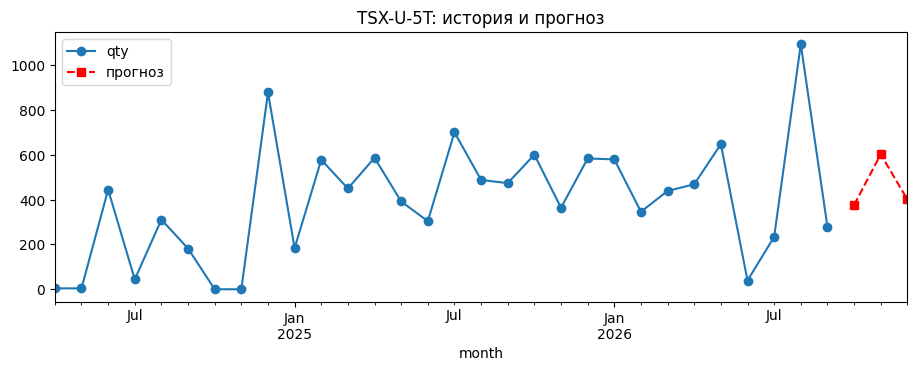

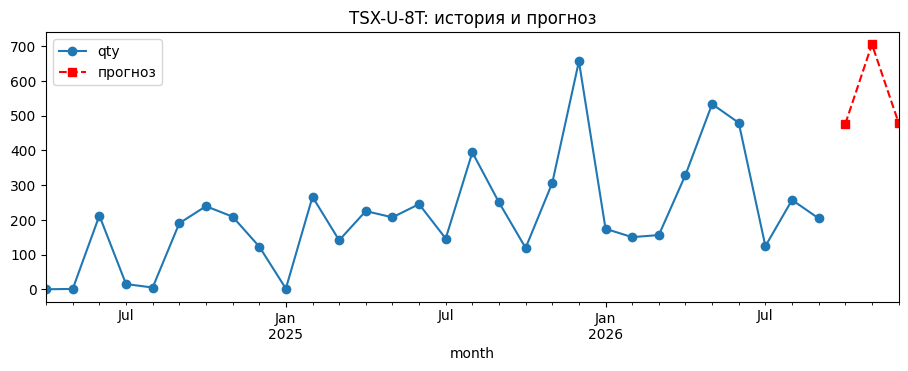

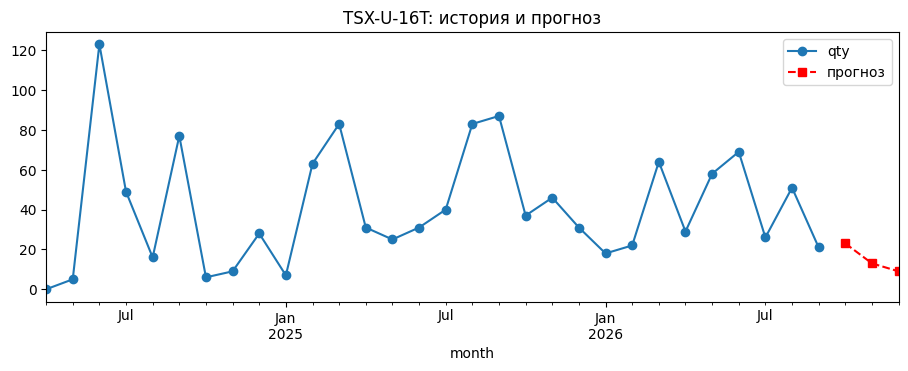

,article,item_name,month,forecast_qty
0,TSX-MC-1GX1GT-FC,Медиаконвертер MC-1GX1GT-FC двойное одномодово...,2026-10-01,2
41,TSX-MC-1GX1GT-FC,Медиаконвертер MC-1GX1GT-FC двойное одномодово...,2026-11-01,0
82,TSX-MC-1GX1GT-FC,Медиаконвертер MC-1GX1GT-FC двойное одномодово...,2026-12-01,0
1,TSX-MC-1GX1GT-SC,Медиаконвертер MC-1GX1GT-SC двойное одномодово...,2026-10-01,3
42,TSX-MC-1GX1GT-SC,Медиаконвертер MC-1GX1GT-SC двойное одномодово...,2026-11-01,1
83,TSX-MC-1GX1GT-SC,Медиаконвертер MC-1GX1GT-SC двойное одномодово...,2026-12-01,1
2,TSX-MC-1GX1GT-SFP,Медиаконвертер MC-1GX1GT-SFP TSX EKF,2026-10-01,5
43,TSX-MC-1GX1GT-SFP,Медиаконвертер MC-1GX1GT-SFP TSX EKF,2026-11-01,0
84,TSX-MC-1GX1GT-SFP,Медиаконвертер MC-1GX1GT-SFP TSX EKF,2026-12-01,3
3,TSX-MC-1GX1GT-ST,Медиаконвертер MC-1GX1GT-ST двойное одномодово...,2026-10-01,0


In [13]:
# Итоговая таблица прогноза + графики
out = forecast.rename(columns={'qty': 'forecast_qty'}).sort_values(['article', 'month'])
out.to_csv('прогноз_спроса.csv', index=False)
print('Сохранено: прогноз_спроса.csv')

for a in top3:
    hist = df[df.article == a].set_index('month').qty
    fc = out[out.article == a].set_index('month').forecast_qty
    ax = hist.plot(marker='o', figsize=(11, 3.5), grid=True, title=f'{a}: история и прогноз')
    fc.plot(ax=ax, marker='s', color='red', linestyle='--', label='прогноз')
    plt.legend(); plt.show()

out.head(12)

## 8. Выводы и рекомендации

1. **Данные.** Отчёт 1С распарсен и сверен с итогами: 41 артикул, 238 клиентов, 30 месяцев (04.2024–09.2026), 23 797 шт, выручка ~138,2 млн. Подготовлены два датасета: `продажи_детально.csv` (артикул × клиент × месяц) и `панель_спроса.csv` (артикул × месяц).
2. **Качество модели.** LightGBM сравнён с наивными бейзлайнами по WAPE/SMAPE на последних 3 месяцах — см. таблицу в разделе 6. Для ходовых позиций (категории A/X-Y) модель даёт рабочий прогноз; для прерывистого хвоста (Z) любая регрессия ограничена — там лучше Croston/TSB или страховой запас.
3. **Прогноз.** `прогноз_спроса.csv` — потребность в штуках по каждому артикулу на 10–12.2026.
4. **Как улучшать:** добавить данные до 04.2024 (годовая сезонность), цены/акции, остатки и сроки поставки; перейти к квантильному прогнозу (P50/P90) для расчёта страхового запаса; пересматривать прогноз ежемесячно.